# Estimation of COVID-19 Pandemic
## Loading Data

We will use data on COVID-19 infected individuals, provided by the [Center for Systems Science and Engineering](https://systems.jhu.edu/)(CSSE) at [Johns Hopkins University](https://jhu.edu/). Dataset is available in [this GitHub Repository](https://github.com/CSSEGISandData/COVID-19).

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (13, 4)  # make figures larger

We can load the most recent data directly from GitHub using `pd.read_csv`. If for some reason the data is not available, you can always use the copy available locally in the `data` folder - just uncomment the line below that defines `base_url`:

In [5]:
# Loading from disk
# base_url = "../../data/COVID/"

# Loading directly from GitHub
base_url = (
    "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/"
)

infected_dataset_url = base_url + "time_series_covid19_confirmed_global.csv"
recovered_dataset_url = base_url + "time_series_covid19_recovered_global.csv"
deaths_dataset_url = base_url + "time_series_covid19_deaths_global.csv"
countries_dataset_url = base_url + "../UID_ISO_FIPS_LookUp_Table.csv"

Let's now load the data for infected individuals and see how the data looks like:

In [6]:
infected = pd.read_csv(infected_dataset_url)
infected.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


We can see that each row of the table defines the number of infected individuals for each country and/or province, and columns correspond to dates. Similar tables can be loaded for other data, such as number of recovered and number of deaths.

In [7]:
recovered = pd.read_csv(recovered_dataset_url)
deaths = pd.read_csv(deaths_dataset_url)

## Making Sense of the Data

From the table above, the role of province column is not clear. Let's see the different values that are present in `Province/State` column:

In [8]:
infected["Province/State"].value_counts()

Province/State
Australian Capital Territory                    1
New South Wales                                 1
Northern Territory                              1
Queensland                                      1
South Australia                                 1
                                               ..
Jersey                                          1
Montserrat                                      1
Pitcairn Islands                                1
Saint Helena, Ascension and Tristan da Cunha    1
Turks and Caicos Islands                        1
Name: count, Length: 91, dtype: int64

From the names we can deduce that countries like Australia and China, have more detailed breakdown by provinces. Let's look for information on China to see the example:

In [9]:
infected[infected["Country/Region"] == "China"]

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
59,Anhui,China,31.8257,117.2264,1,9,15,39,60,70,...,2275,2275,2275,2275,2275,2275,2275,2275,2275,2275
60,Beijing,China,40.1824,116.4142,14,22,36,41,68,80,...,40774,40774,40774,40774,40774,40774,40774,40774,40774,40774
61,Chongqing,China,30.0572,107.8740,6,9,27,57,75,110,...,14715,14715,14715,14715,14715,14715,14715,14715,14715,14715
62,Fujian,China,26.0789,117.9874,1,5,10,18,35,59,...,17122,17122,17122,17122,17122,17122,17122,17122,17122,17122
63,Gansu,China,35.7518,104.2861,0,2,2,4,7,14,...,1742,1742,1742,1742,1742,1742,1742,1742,1742,1742
64,Guangdong,China,23.3417,113.4244,26,32,53,78,111,151,...,103248,103248,103248,103248,103248,103248,103248,103248,103248,103248
65,Guangxi,China,23.8298,108.7881,2,5,23,23,36,46,...,13371,13371,13371,13371,13371,13371,13371,13371,13371,13371
66,Guizhou,China,26.8154,106.8748,1,3,3,4,5,7,...,2534,2534,2534,2534,2534,2534,2534,2534,2534,2534
67,Hainan,China,19.1959,109.7453,4,5,8,19,22,33,...,10483,10483,10483,10483,10483,10483,10483,10483,10483,10483
68,Hebei,China,39.5490,116.1306,1,1,2,8,13,18,...,3292,3292,3292,3292,3292,3292,3292,3292,3292,3292


## Pre-processing the Data

We are not interested in breaking countries down to further territories, thus we would first get rid of this breakdown and *add information on all territories together*, to **get info for the whole country**. This can be done using `grouby`:

In [10]:
infected = infected.groupby("Country/Region").sum()
recovered = recovered.groupby("Country/Region").sum()
deaths = deaths.groupby("Country/Region").sum()

infected.head()

,Province/State,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,33.93911,67.709953,0,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
Albania,0,41.15330,20.168300,0,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
Algeria,0,28.03390,1.659600,0,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
Andorra,0,42.50630,1.521800,0,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
Angola,0,-11.20270,17.873900,0,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


Notice that after using `groupby`, all DataFrames now have as index the `Country/Region` information. We can thus access the data for a specific country by using `loc`. Since loc returns the row as a Series, we index from position 3 (the first date); we don't want the first three columns in the plot!

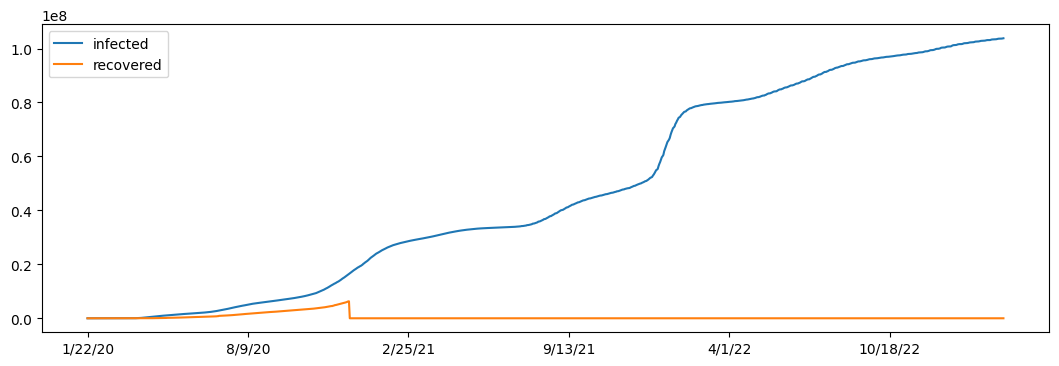

In [11]:
infected.loc["US"][3:].plot(label="infected")
recovered.loc["US"][3:].plot(label="recovered")
plt.legend()
plt.show()

> Since we don't need them, we can drop the first three columns altogether:

In [12]:
infected.drop(columns=["Province/State", "Lat", "Long"], inplace=True)
recovered.drop(columns=["Province/State", "Lat", "Long"], inplace=True)
deaths.drop(columns=["Province/State", "Lat", "Long"], inplace=True)

## Investigating the Data

Let's now switch to investigating a specific country. Let's create a frame that contains the data on infections indexed by date:

In [13]:
def mkframe(country):
    """
    Creates a table with three columns for infected, recovered and death
    cases, indexed by the specific date.

    :param country: The country we are interested in.
    """
    df = pd.DataFrame(
        {
            "infected": infected.loc[country],
            "recovered": recovered.loc[country],
            "deaths": deaths.loc[country],
        }
    )

    # The format we pass (%m/%d/%y), must be the format of the string dates
    # in the existing DataFrame.
    df.index = pd.to_datetime(df.index, format="%m/%d/%y")
    return df

In [14]:
df = mkframe("US")
df

,infected,recovered,deaths
2020-01-22,1,0,0
2020-01-23,1,0,0
2020-01-24,2,0,0
2020-01-25,2,0,0
2020-01-26,5,0,0
...,...,...,...
2023-03-05,103646975,0,1122134
2023-03-06,103655539,0,1122181
2023-03-07,103690910,0,1122516
2023-03-08,103755771,0,1123246


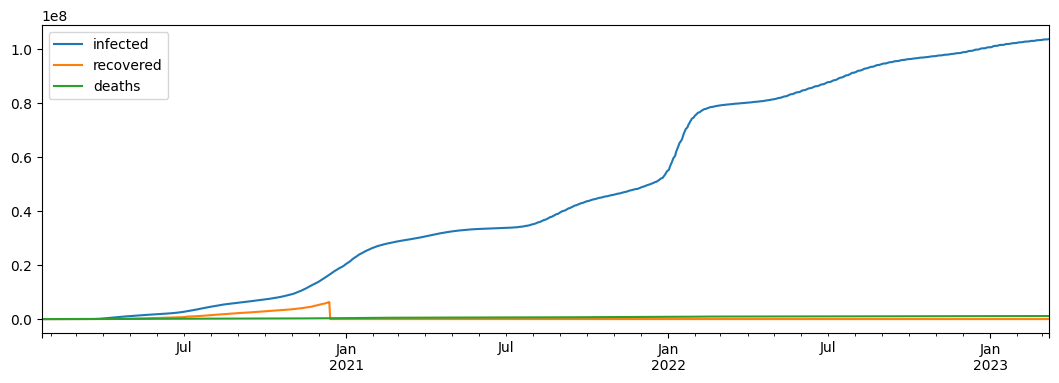

In [15]:
df.plot()
plt.show()

Now let's compute the number of new infected people each day. This will allow us to see the speed at which pandemic progresses. The easiest way to do it is to use `diff` (computes the difference of a Series element with the element in the previous row):

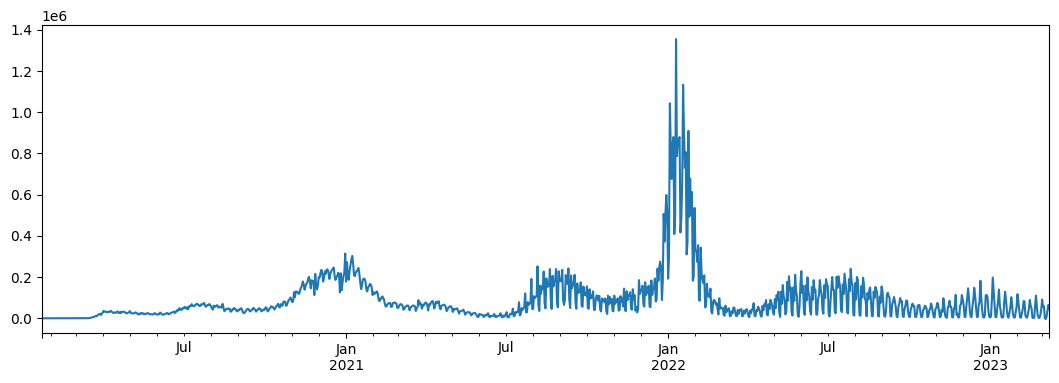

In [16]:
df["ninfected"] = df["infected"].diff()
df["ninfected"].plot()
plt.show()

We can see high fluctuations in data. Let's look closer at one of the months:

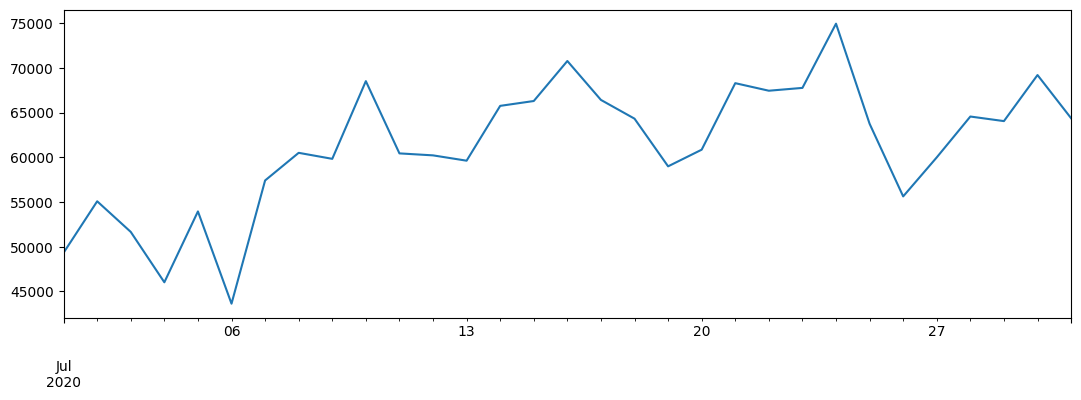

In [17]:
df[(df.index.year == 2020) & (df.index.month == 7)]["ninfected"].plot()
plt.show()

It clearly looks like there are weekly fluctuations in data. Because we want to be able to see the trends, it makes sense to smooth out the curve by computing **rolling average** (i.e. for each day we will compute the average value of the previous several days)

Here, the size of the moving window is seven i.e. for each window use seven observations

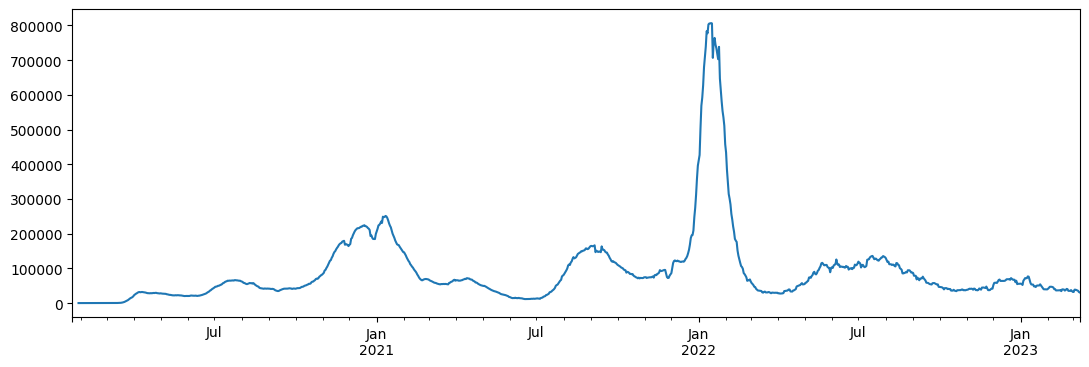

In [18]:
df["ninfav"] = df["ninfected"].rolling(window=7).mean()
df["ninfav"].plot()
plt.show()

In order to be able to compare several countries, we might want to take the country's population into account, and compare the percentage of infected individuals with respect to country's population. In order to get country's population, let's load the dataset of countries:

In [19]:
countries = pd.read_csv(countries_dataset_url)
countries

,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Country_Region,Lat,Long_,Combined_Key,Population
0,4,AF,AFG,4.0,NaN,NaN,NaN,Afghanistan,33.939110,67.709953,Afghanistan,38928341.0
1,8,AL,ALB,8.0,NaN,NaN,NaN,Albania,41.153300,20.168300,Albania,2877800.0
2,10,AQ,ATA,10.0,NaN,NaN,NaN,Antarctica,-71.949900,23.347000,Antarctica,NaN
3,12,DZ,DZA,12.0,NaN,NaN,NaN,Algeria,28.033900,1.659600,Algeria,43851043.0
4,20,AD,AND,20.0,NaN,NaN,NaN,Andorra,42.506300,1.521800,Andorra,77265.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4316,84056037,US,USA,840.0,56037.0,Sweetwater,Wyoming,US,41.659439,-108.882788,"Sweetwater, Wyoming, US",42343.0
4317,84056039,US,USA,840.0,56039.0,Teton,Wyoming,US,43.935225,-110.589080,"Teton, Wyoming, US",23464.0
4318,84056041,US,USA,840.0,56041.0,Uinta,Wyoming,US,41.287818,-110.547578,"Uinta, Wyoming, US",20226.0
4319,84056043,US,USA,840.0,56043.0,Washakie,Wyoming,US,43.904516,-107.680187,"Washakie, Wyoming, US",7805.0


Because this dataset contains information on both countries and provinces, to get the population of the whole country we need to be a little bit clever:

In [20]:
countries[(countries["Country_Region"] == "US") & (countries["Province_State"].isna())]

,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Country_Region,Lat,Long_,Combined_Key,Population
915,840,US,USA,840.0,NaN,NaN,NaN,US,40.0,-100.0,US,329466283.0


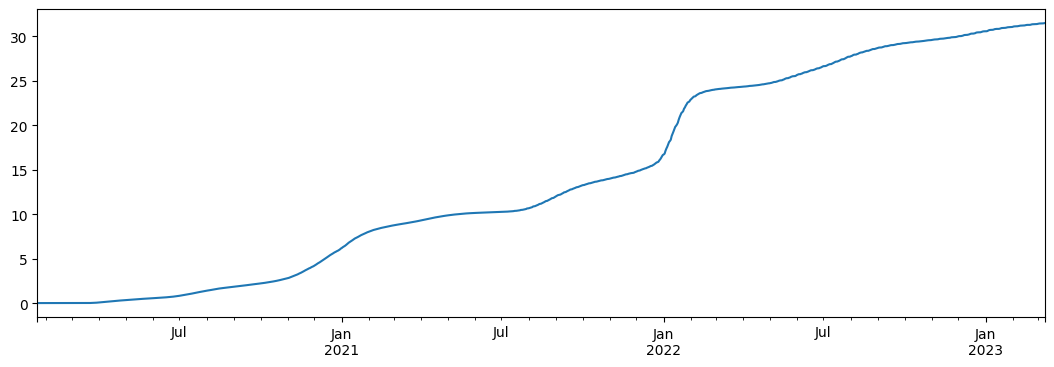

In [26]:
pop = countries[(countries["Country_Region"] == "US") & (countries["Province_State"].isna())]["Population"].iloc[0]
df["pinfected"] = (df["infected"] / pop) * 100
df["pinfected"].plot()
plt.show()

## Computing $R_t$

To see how infectious is the disease, we look at the **basic reproduction number** $R_0$, which indicates the number of people that an infected person would further infect. When $R_0$ is more than 1, the epidemic is likely to spread.

$R_0$ is a property of the disease itself, and does not take into account some protective measures that people may take to slow down the pandemic. During the pandemic progression, we can estimate the reproduction number $R_t$ at any given time $t$. It has been shown that this number can be roughly estimated by taking a window of 8 days, and computing

<div style="text-align:center;">

$\LARGE R_t = \frac{I_{t-7}+I_{t-6}+I_{t-5}+I_{t-4}}{I_{t-3}+I_{t-2}+I_{t-1}+I_{t}}$

</div>

where $I_t$ is the number of newly infected individuals on day $t$.

Let's compute $R_t$ for our pandemic data. To do this, we will take a rolling window of 8 `ninfected` values, and apply the function to compute the ratio above:

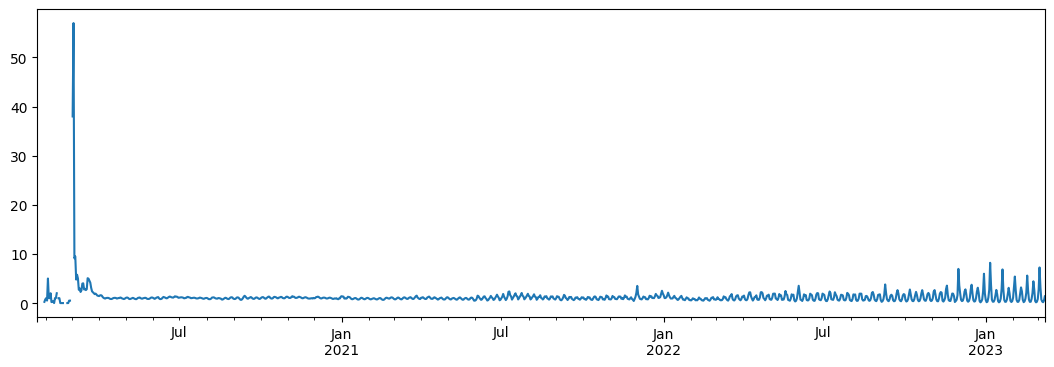

In [28]:
df["Rt"] = df["ninfected"].rolling(8).apply(lambda x: x[4:].sum() / x[:4].sum())
df["Rt"].plot()
plt.show()

You can see that there are some gaps in the graph. Those can be caused by either `NaN`, if `inf` values being present in the dataset. `inf` may be caused by division by 0, and `NaN` can indicate missing data, or no data available to compute the result (like in the very beginning of our frame, where rolling window of width 8 is not yet available). To make the graph nicer, we need to fill those values using `replace` and `fillna` function.

Let's further look at the beginning of the pandemic. We will also limit the y-axis values to show only values velow 6, in order to see better, and draw horizontal line at 1.

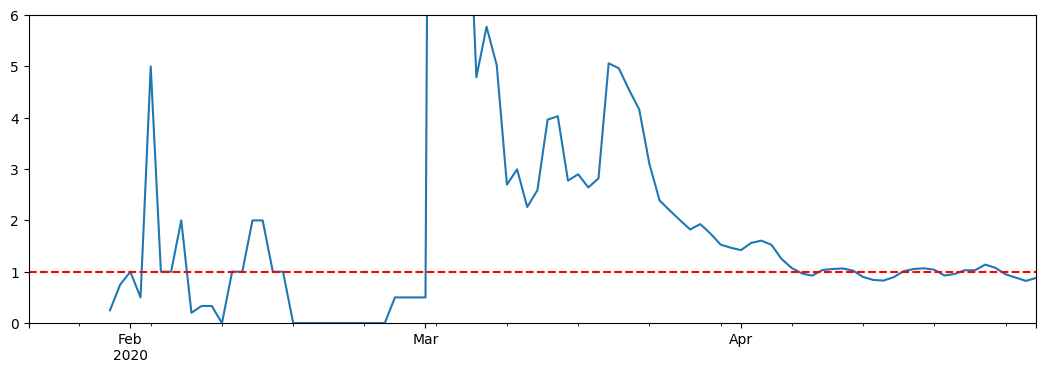

In [33]:
ax = df[df.index < "2020-05-01"]["Rt"].replace(np.inf, np.nan).ffill().plot()
ax.set_ylim([0, 6])
ax.axhline(1, linestyle="--", color="red")
plt.show()

Another interesting indicator of the pandemic is the **derivative**, or **daily difference** in new cases. It allows us to see clearly when pandemic is increasing of declining.

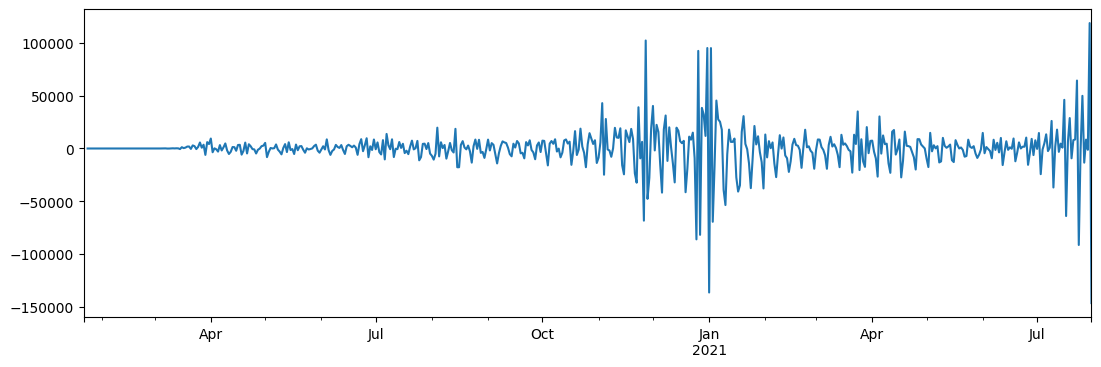

In [35]:
df[df.index < "2021-08-01"]["ninfected"].diff().plot()
plt.show()

Given the fact that there are a lot of fluctuations in data caused by reporting, it makes sense to smooth the curve by running rolling average to get the overall picture. Let's again focus on the first months of the pandemic:

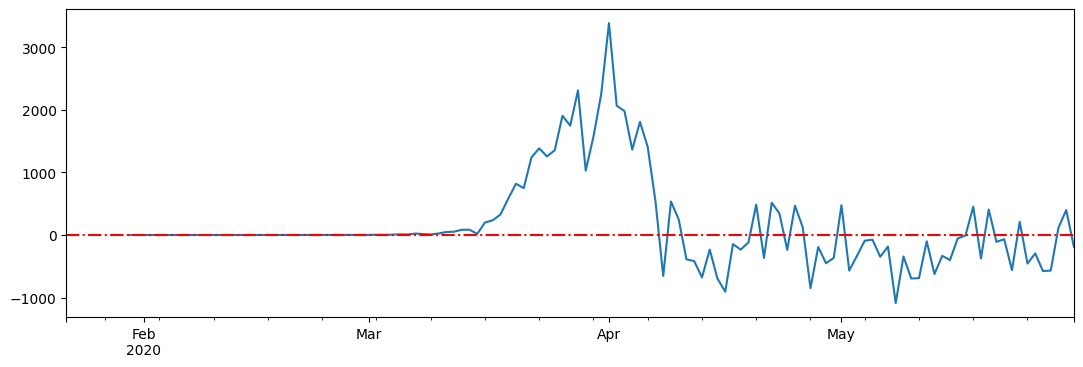

In [36]:
ax = df[df.index < "2020-06-01"]["ninfected"].diff().rolling(7).mean().plot()
ax.axhline(0, linestyle="-.", color="red")
plt.show()

# CHALLENGE
#### See the spread of the pandemic in different countries

In [65]:
# Use the mkframe() function to create DataFrames with infected,
# recovered and deaths for a few other countries
df_UK = mkframe("United Kingdom")
df_FR = mkframe("France")
df_IN = mkframe("India")
df_RU = mkframe("Russia")
df_BR = mkframe("Brazil")

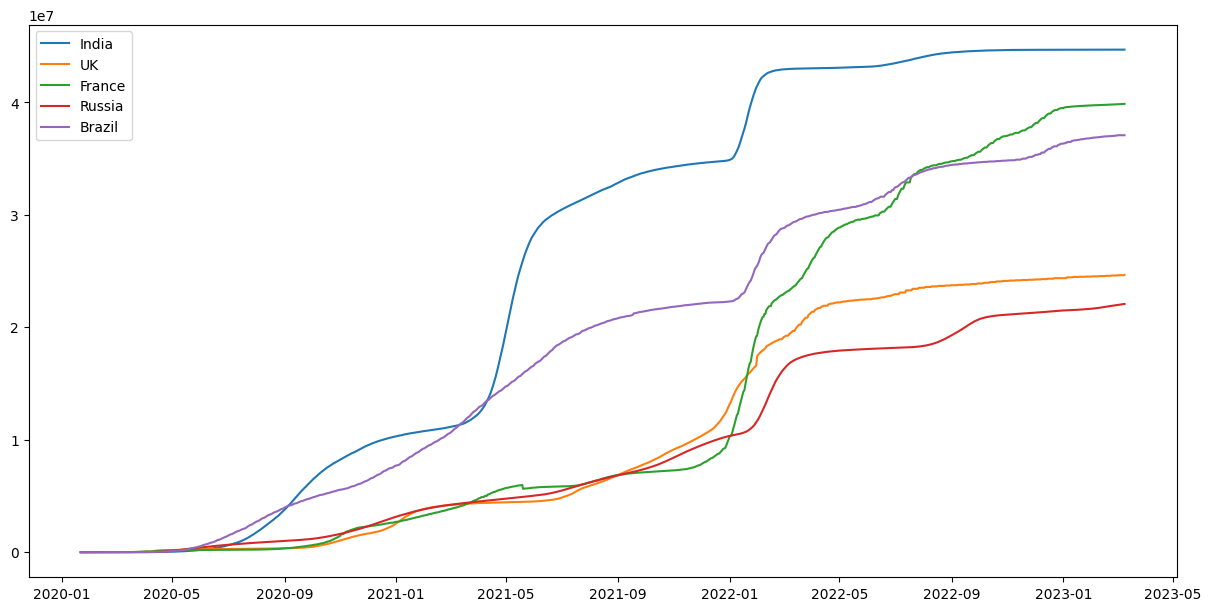

In [66]:
fig, ax = plt.subplots(figsize=(12, 6), layout="constrained")
ax.plot(df_IN["infected"], label="India")
ax.plot(df_UK["infected"], label="UK")
ax.plot(df_FR["infected"], label="France")
ax.plot(df_RU["infected"], label="Russia")
ax.plot(df_BR["infected"], label="Brazil")
ax.legend()

plt.show()

#### Plot $R_t$ graphs for several countries on one plot for comparison, or make several plots side-by-side

In [ ]:
def calc_rt(country):
    df = mkframe(country)
    df["ninfected"] = df["infected"].diff()
    df["Rt"] = df["ninfected"].rolling(8).apply(lambda x: x[4:].sum() / x[:4].sum())
    df["Rt"] = df["Rt"].replace(np.inf, np.nan).ffill()

    return df["Rt"]

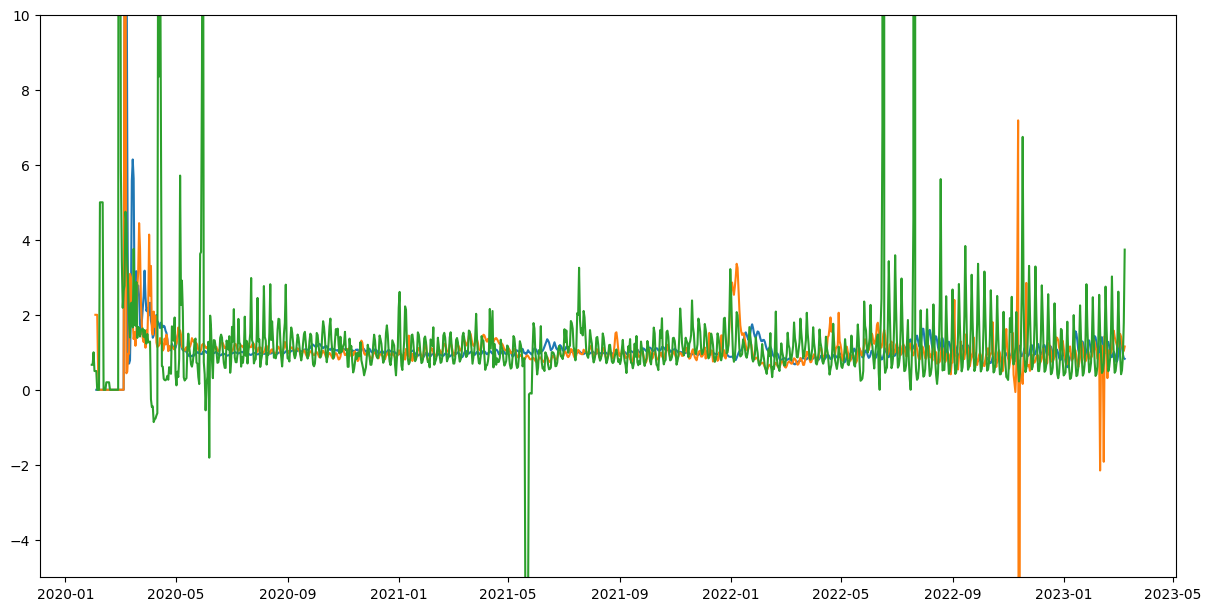

In [105]:
rt_in = calc_rt("India")
# rt_in
rt_ru = calc_rt("Russia")
# rt_uk = calc_rt("United Kingdom")
rt_fr = calc_rt("France")

fig, ax = plt.subplots(figsize=(12, 6), layout="constrained")
ax.set_ylim([-5, 10])
ax.plot(rt_ru)
ax.plot(rt_in)
ax.plot(rt_fr)

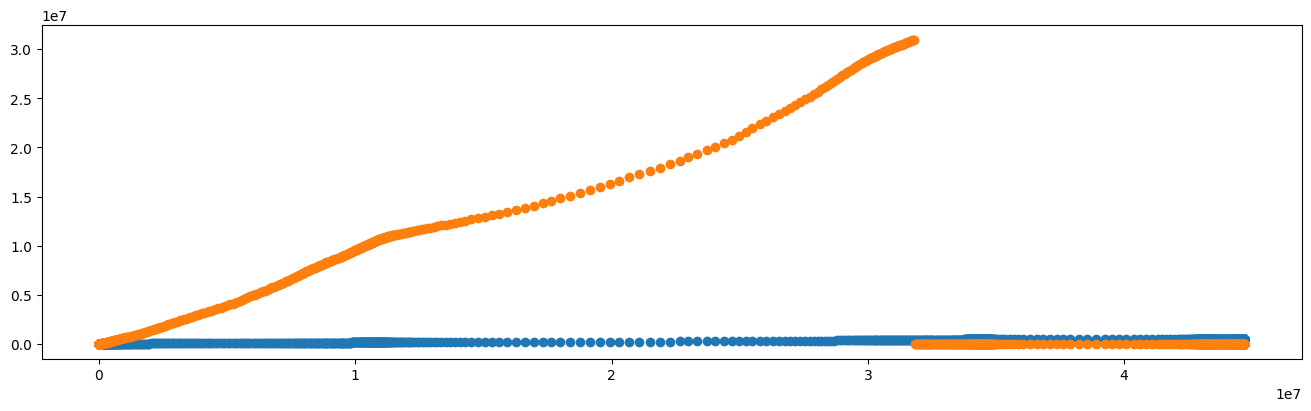

In [116]:
# Use only US data for correlations
fig, ax = plt.subplots(layout="constrained")
ax.scatter(df["infected"], df["deaths"])
ax.scatter(df["infected"], df["recovered"])

In [114]:
df[["infected", "recovered", "deaths"]].corr()

,infected,recovered,deaths
infected,1.000000,-0.160762,0.995584
recovered,-0.160762,1.000000,-0.147612
deaths,0.995584,-0.147612,1.000000
